# 2-3. 일원분산분석(ANOVA)

세 지점 A, B, C의 일별 판매량 평균에 차이가 있는지 확인한다.

## 이 실습의 학습 기준

이 노트북은 한 가지 함수의 결과만 확인하지 않고 다음 흐름으로 학습한다.

1. 데이터 구조에 맞는 검정 방법과 가정을 확인한다.
2. 같은 목적의 방법이 여러 개면 모두 실행해 결과를 비교한다.
3. 일부러 적합하지 않은 방법도 비교할 때는, 왜 최종 결론에 사용하지 않는지 밝힌다.
4. 전제검정 결과가 본 검정 선택에 어떻게 연결되는지 확인한다.
5. p-value뿐 아니라 차이의 방향과 크기까지 해석한다.
6. p-value가 `0.0000`으로 보이는 것은 반올림 결과이며, 실제 확률이 0이라는 뜻은 아니다.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from matplotlib import pyplot as plt

plt.rcParams["font.family"] = "Apple SD Gothic Neo"
plt.rcParams["axes.unicode_minus"] = False

sales_df = pd.read_csv(
    "datas2/지점별_일별판매량.csv",
    encoding="euc-kr"
)

print(sales_df.head())
print(sales_df.columns)

   일자  지점A  지점B  지점C
0   1  124  118  216
1   2  147  141  214
2   3  129  130  212
3   4  123  127  179
4   5  147  107  222
Index(['일자', '지점A', '지점B', '지점C'], dtype='str')


## 1. 데이터 분리와 가설 설정

- 귀무가설(H₀): 지점 A, B, C의 평균 판매량은 모두 같다.
- 대립가설(H₁): 세 지점 중 적어도 하나의 평균 판매량은 다르다.

세 쌍을 각각 t-검정하면 다중검정으로 제1종 오류가 커질 수 있으므로, 전체 평균 차이는 먼저 ANOVA로 검정한다.

In [2]:
branch_a = sales_df["지점A"].dropna().to_numpy()
branch_b = sales_df["지점B"].dropna().to_numpy()
branch_c = sales_df["지점C"].dropna().to_numpy()

for name, values in [("A", branch_a), ("B", branch_b), ("C", branch_c)]:
    print(
        f"지점 {name} - 개수: {len(values)}, "
        f"평균: {np.mean(values):.2f}, 표준편차: {np.std(values, ddof=1):.2f}"
    )

지점 A - 개수: 30, 평균: 137.87, 표준편차: 11.67
지점 B - 개수: 30, 평균: 136.47, 표준편차: 15.55
지점 C - 개수: 30, 평균: 200.10, 표준편차: 16.98


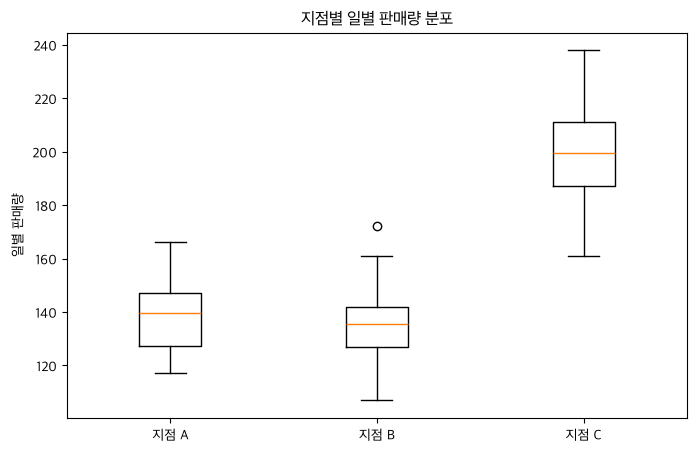

In [3]:
plt.figure(figsize=(8, 5))
plt.boxplot([branch_a, branch_b, branch_c])
plt.xticks([1, 2, 3], ["지점 A", "지점 B", "지점 C"])
plt.ylabel("일별 판매량")
plt.title("지점별 일별 판매량 분포")
plt.show()

### 1-1. 지점별 KS-test와 Shapiro-Wilk 비교

각 지점에 두 정규성 검정을 모두 적용한다. KS-test는 표본에서 평균과 표준편차를 추정한 학습용 비교이고, 각 지점의 표본 수가 30개이므로 Shapiro-Wilk를 주 판단으로 사용한다.

- 귀무가설(H₀): 해당 지점의 판매량은 정규분포를 따른다.
- 대립가설(H₁): 해당 지점의 판매량은 정규분포를 따르지 않는다.

In [4]:
branch_normality_rows = []

for branch_name, branch_values in [
    ("지점 A", branch_a),
    ("지점 B", branch_b),
    ("지점 C", branch_c)
]:
    branch_mean = np.mean(branch_values)
    branch_std = np.std(branch_values, ddof=1)
    ks_result = stats.kstest(
        branch_values,
        stats.norm.cdf,
        args=(branch_mean, branch_std)
    )
    shapiro_result = stats.shapiro(branch_values)

    branch_normality_rows.extend([
        {
            "지점": branch_name,
            "검정 방법": "KS-test",
            "검정통계량": ks_result.statistic,
            "p-value": ks_result.pvalue
        },
        {
            "지점": branch_name,
            "검정 방법": "Shapiro-Wilk",
            "검정통계량": shapiro_result.statistic,
            "p-value": shapiro_result.pvalue
        }
    ])

branch_normality_comparison = pd.DataFrame(branch_normality_rows)
branch_normality_comparison["결론"] = branch_normality_comparison["p-value"].apply(
    lambda p: "정규성 위반 증거 부족" if p > 0.05 else "정규성 위반 가능성"
)

display(branch_normality_comparison.round(4))

,지점,검정 방법,검정통계량,p-value,결론
0,지점 A,KS-test,0.1165,0.7671,정규성 위반 증거 부족
1,지점 A,Shapiro-Wilk,0.9654,0.4219,정규성 위반 증거 부족
2,지점 B,KS-test,0.1276,0.6660,정규성 위반 증거 부족
3,지점 B,Shapiro-Wilk,0.9794,0.8099,정규성 위반 증거 부족
4,지점 C,KS-test,0.0758,0.9901,정규성 위반 증거 부족
5,지점 C,Shapiro-Wilk,0.9821,0.8772,정규성 위반 증거 부족


### 1-2. Levene 등분산성 검정

일반 일원분산분석은 세 집단의 분산이 같다고 가정한다. Levene 검정 결과에 따라 일반 ANOVA와 Welch ANOVA 중 주 결과를 선택한다.

- 귀무가설(H₀): 세 지점의 판매량 분산은 같다.
- 대립가설(H₁): 세 지점 중 적어도 하나의 판매량 분산은 다르다.

In [5]:
levene_result = stats.levene(
    branch_a,
    branch_b,
    branch_c,
    center="median"
)

print(f"Levene 검정통계량: {levene_result.statistic:.4f}")
print(f"p-value: {levene_result.pvalue:.4f}")
print("일반 ANOVA를 주 결과로 사용:", levene_result.pvalue > 0.05)

Levene 검정통계량: 1.2446
p-value: 0.2931
일반 ANOVA를 주 결과로 사용: True


## 2. 일반 ANOVA와 Welch ANOVA 비교

- 일반 ANOVA: 집단별 분산이 같다고 가정한다.
- Welch ANOVA: 집단별 분산이 같지 않아도 사용할 수 있다.

두 방식을 모두 실행하되, 최종 결론에는 Levene 결과에 맞는 방식을 사용한다.

In [6]:
classic_anova = stats.f_oneway(
    branch_a,
    branch_b,
    branch_c,
    equal_var=True
)
welch_anova = stats.f_oneway(
    branch_a,
    branch_b,
    branch_c,
    equal_var=False
)

anova_comparison = pd.DataFrame({
    "검정 방법": ["일반 ANOVA", "Welch ANOVA"],
    "등분산 가정": [True, False],
    "F-통계량": [classic_anova.statistic, welch_anova.statistic],
    "p-value": [classic_anova.pvalue, welch_anova.pvalue]
})
anova_comparison["결론"] = anova_comparison["p-value"].apply(
    lambda p: "적어도 한 평균이 다름" if p <= 0.05 else "평균 차이 증거 부족"
)

display(anova_comparison)

if levene_result.pvalue > 0.05:
    selected_anova_name = "일반 ANOVA"
    anova_result = classic_anova
else:
    selected_anova_name = "Welch ANOVA"
    anova_result = welch_anova

print("Levene 검정에 따라 선택한 방법:", selected_anova_name)
print(f"선택한 검정의 p-value: {anova_result.pvalue:.6g}")

,검정 방법,등분산 가정,F-통계량,p-value,결론
0,일반 ANOVA,True,178.438254,1.633742e-31,적어도 한 평균이 다름
1,Welch ANOVA,False,155.562458,1.121908e-23,적어도 한 평균이 다름


Levene 검정에 따라 선택한 방법: 일반 ANOVA
선택한 검정의 p-value: 1.63374e-31


## 3. 보정 전 쌍별 t-검정과 Tukey 사후검정 비교

ANOVA는 어느 지점이 다른지 알려주지 않는다. 지점 쌍을 단순 t-검정한 p-value와 다중비교를 보정한 Tukey p-value를 함께 확인한다.

- 보정 전 쌍별 t-검정: 여러 번 반복하면 우연한 유의성이 증가할 수 있다.
- Tukey HSD: 모든 쌍을 동시에 비교하면서 전체 제1종 오류를 조절한다.

현재는 Levene 검정에서 등분산 위반 증거가 없으므로 Tukey를 사용한다. 등분산 위반 시에는 Welch ANOVA 뒤에 Games-Howell 같은 사후검정을 고려한다.

In [7]:
pair_specs = [
    ("A - B", branch_a, branch_b, 0, 1),
    ("A - C", branch_a, branch_c, 0, 2),
    ("B - C", branch_b, branch_c, 1, 2)
]

tukey_result = stats.tukey_hsd(branch_a, branch_b, branch_c)
pairwise_rows = []

for label, first, second, first_index, second_index in pair_specs:
    raw_t_result = stats.ttest_ind(first, second, equal_var=True)
    pairwise_rows.append({
        "비교": label,
        "평균 차이": np.mean(first) - np.mean(second),
        "보정 전 t-test p-value": raw_t_result.pvalue,
        "Tukey 보정 p-value": tukey_result.pvalue[first_index, second_index]
    })

pairwise_comparison = pd.DataFrame(pairwise_rows)
pairwise_comparison["보정 전 유의"] = (
    pairwise_comparison["보정 전 t-test p-value"] <= 0.05
)
pairwise_comparison["Tukey 유의"] = (
    pairwise_comparison["Tukey 보정 p-value"] <= 0.05
)

display(pairwise_comparison.round(4))

,비교,평균 차이,보정 전 t-test p-value,Tukey 보정 p-value,보정 전 유의,Tukey 유의
0,A - B,1.4000,0.6947,0.9297,False,False
1,A - C,-62.2333,0.0000,0.0000,True,True
2,B - C,-63.6333,0.0000,0.0000,True,True


## 4. 분석 결과

- 세 지점 모두 KS-test와 Shapiro-Wilk에서 정규성 위반의 충분한 증거가 없었다.
- Levene 검정 p-value는 0.2931이므로 일반 ANOVA를 주 결과로 선택했다.
- 일반 ANOVA와 Welch ANOVA 모두 세 지점 중 적어도 하나의 평균이 다르다는 결론을 보였다.
- 보정 전 t-검정과 Tukey 모두 A-B는 유의하지 않고 A-C와 B-C는 유의하다는 같은 결론을 보였다.
- 지점 C의 평균은 지점 A보다 약 62.23, 지점 B보다 약 63.63 높았다.
- 최종적으로 전체 차이는 주로 지점 C의 높은 판매량에서 비롯된 것으로 해석한다.